# M5A5 - Segmentação de Falhas em Tecidos

> **Resumo:** Como datasets de falhas industriais reais são raros (segredo de fábrica), usamos uma **proxy task**: classificação de texturas com o dataset **DTD** (47 classes). Refinamos uma **ResNet-18** e, no fim, classificamos a "textura" do pelo do Sonic e do Tails.

> 📝 **Proxy task:** quando faltam dados do problema real, treina-se numa tarefa parecida e disponível (aqui, texturas genéricas) cujas features transferem para o problema-alvo.

> ⚠️ **GPU recomendada** (Ambiente de execução → Alterar o tipo → GPU T4): são 100 épocas de treino da ResNet-18.

Na prática de hoje vamos trabalhar com o problema de detecção e classificação de padrões em tecidos e texturas.

Em cenários industriais reais, a **segmentação de falhas em tecidos** (como rasgos, manchas e irregularidades) é vital para a automação de controle de qualidade na indústria têxtil. No entanto, coletar e anotar bases de dados públicas de falhas industriais reais é um grande desafio devido a segredos de negócio e direitos de privacidade das fábricas.

Diante da escassez desses datasets industriais, os desenvolvedores de visão computacional utilizam comumente tarefas substitutas (**proxy tasks**), como a classificação de texturas. Para isso, usaremos o dataset **DTD (Describable Textures Dataset)** do PyTorch. Em vez de segmentação pixel a pixel, refinaremos uma rede convolucional **ResNet-18** para classificar diferentes tipos de texturas visuais complexas.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Validar Modelo
- Próximos passos
- Atividades Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision tqdm ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.0 MB/s eta 0:00:00


Importar as bibliotecas

In [2]:
import torch
import torchvision
from tqdm.notebook import tqdm

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

Referência: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.DTD.html

In [3]:
# Define transforms: Resize and normalize images as expected by most pre-trained models (e.g., ImageNet models use 224x224 input).
# Data augmentation is also crucial for better performance.
image_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224), # Common input size for ImageNet models
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the dataset
# Set download=True to automatically fetch the dataset if not already present
train_dataset = torchvision.datasets.DTD(root="./data", split="train", download=True, transform=image_transforms)
val_dataset = torchvision.datasets.DTD(root="./data", split="val", download=True, transform=image_transforms)
test_dataset = torchvision.datasets.DTD(root="./data", split="test", download=True, transform=image_transforms)

# Define DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
_ = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

100%|██████████| 625M/625M [00:27<00:00, 22.5MB/s]


## Refinar Modelo

Na prática de hoje iremos refinar o modelo **ResNets** disponível no torchvision.

In [4]:
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

num_classes = 47

# Get the number of input features for the final layer
in_features = model.fc.in_features

# Replace the existing fully connected layer with a new one
model.fc = torch.nn.Linear(in_features, num_classes)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Treinamento do modelo
model.train()
epochs = 100 # Alterar para treinar mais epocas.
for epoch in tqdm(range(epochs)):
    iteration = 0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if iteration % 100 == 0:
            print(f"Total loss: {loss.item()}")
        iteration += 1



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


  0%|          | 0/100 [00:00<?, ?it/s]

Total loss: 4.087777137756348
Total loss: 2.7023696899414062
Total loss: 1.701751708984375
Total loss: 0.9299372434616089
Total loss: 0.953045666217804
Total loss: 0.8745107054710388
Total loss: 0.6174256205558777
Total loss: 0.4617460072040558
Total loss: 0.40347573161125183
Total loss: 0.16567662358283997
Total loss: 0.2742963135242462
Total loss: 0.14292974770069122
Total loss: 0.26858431100845337
Total loss: 0.21246305108070374
Total loss: 0.08186984062194824
Total loss: 0.15348932147026062
Total loss: 0.11474484950304031
Total loss: 0.09238230437040329
Total loss: 0.06574106216430664
Total loss: 0.10917909443378448
Total loss: 0.08206604421138763
Total loss: 0.043782562017440796
Total loss: 0.028653258457779884
Total loss: 0.0514972060918808
Total loss: 0.028552871197462082
Total loss: 0.0567958727478981
Total loss: 0.05133070796728134
Total loss: 0.024234868586063385
Total loss: 0.0451369509100914
Total loss: 0.024859972298145294
Total loss: 0.024551065638661385
Total loss: 0.034

## Validar Modelo

Agora vamos testar o nosso modelo.

In [5]:
num_correct = 0
num_samples = 0

# Set model to evaluation mode
model.eval()

# Disable gradient calculation for inference
with torch.no_grad():
    for images, labels in test_loader:
            x = images.to(device)
            y = labels.to(device)

            scores = model(x)

            # Get the index (class) with the highest score
            _, predictions = scores.max(1)

            # Count correct predictions
            num_correct += (predictions == y).sum().item()
            # Count total samples
            num_samples += predictions.size(0)

    # Calculate and print accuracy
    accuracy = float(num_correct) / float(num_samples) * 100
    print(f'Got {num_correct} / {num_samples} with accuracy {accuracy:.2f}%')

Got 1233 / 1880 with accuracy 65.59%


## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.pytorch.org/vision/main/generated/torchvision.datasets.DTD.html
- https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html
- https://huggingface.co/datasets
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [x] **Classificação de Texturas do Team Sonic** — resolvida logo abaixo (leve: só inferência no modelo já treinado).
- [x] **Tempo de treino vs acurácia** — resolvida na seção opcional/pesada no fim (treina uma versão curta e compara).
- [ ] **Sugestão livre:** altere o batch/learning rate e veja como muda a convergência.

  Para exercitar o classificador de texturas ResNet-18 treinado no Describable Textures Dataset (DTD), vamos submeter texturas reais extraídas do Team Sonic!
  Recortaremos a região central dos pelos do Sonic (`img/sonic.jpg`) e do Tails (`img/tails.jpg`), aplicaremos o mesmo pré-processamento de normalização e verificaremos qual das 47 classes de textura do dataset (como *furry*, *striped*, *dotted*, *stratified*) a rede associa a cada personagem.

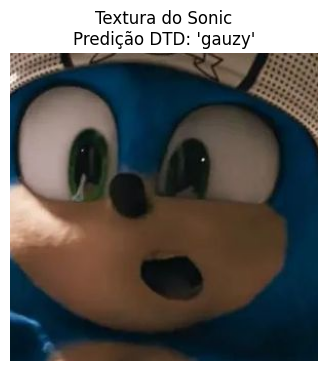

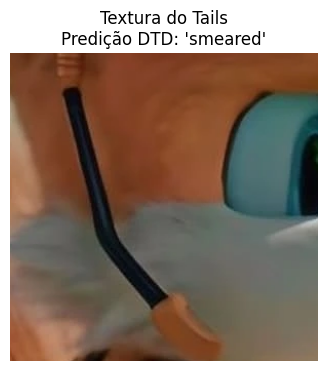

In [6]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def classify_sonic_texture(image_name, path_to_image):
    if not os.path.exists(path_to_image):
        print(f"Erro: {image_name} não encontrado em {path_to_image}")
        return

    # Carregar imagem original
    img = Image.open(path_to_image).convert("RGB")

    # Recortar patch central de textura (300x300)
    w, h = img.size
    crop_size = min(w, h, 300)
    left = (w - crop_size)/2
    top = (h - crop_size)/2
    right = (w + crop_size)/2
    bottom = (h + crop_size)/2
    img_cropped = img.crop((left, top, right, bottom))

    # Aplicar as mesmas transformações de validação
    input_tensor = image_transforms(img_cropped).unsqueeze(0).to(device)

    # Executar inferência
    model.eval()
    with torch.no_grad():
        scores = model(input_tensor)
        _, pred_idx = scores.max(1)
        pred_class = train_dataset.classes[pred_idx.item()]

    # Exibir resultados
    plt.figure(figsize=(4, 4))
    plt.imshow(img_cropped)
    plt.axis('off')
    plt.title(f"Textura do {image_name}\nPredição DTD: '{pred_class}'")
    plt.show()

# Buscar caminhos das imagens dos personagens
sonic_path = "/content/sonic.jpg"
if not os.path.exists(sonic_path): sonic_path = "sonic.jpg"
if not os.path.exists(sonic_path): sonic_path = "../../img/sonic.jpg"
if not os.path.exists(sonic_path): sonic_path = "img/sonic.jpg"

tails_path = "/content/tails.jpg"
if not os.path.exists(tails_path): tails_path = "tails.jpg"
if not os.path.exists(tails_path): tails_path = "../../img/tails.jpg"
if not os.path.exists(tails_path): tails_path = "img/tails.jpg"

classify_sonic_texture("Sonic", sonic_path)
classify_sonic_texture("Tails", tails_path)

> 📝 **O que esperar:** o classificador foi treinado só nas texturas do DTD, então ele "força" o pelo dos personagens em alguma das 47 classes (ex.: *furry*, *fuzzy*, *gauzy*, *smeared*...). A predição exata **varia a cada treino** (não fixamos seed) — o interessante é notar que a rede tenta descrever a *textura*, não o personagem. As predições aparecem nos títulos das figuras acima.

---
# ⏸️ Ponto de parada

## Atividade (opcional/pesada): Tempo de Treino vs Acurácia

A pergunta da atividade é: *treinar por menos tempo mantém a performance?* Vamos treinar uma
ResNet-18 por apenas **5 épocas** e comparar a acurácia no teste com o modelo completo (100 épocas).

In [7]:
# Treina uma ResNet18 "rápida" (5 épocas) e compara com o modelo completo (100 épocas, acima)
model_rapido = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
model_rapido.fc = torch.nn.Linear(model_rapido.fc.in_features, num_classes)
model_rapido = model_rapido.to(device)
opt_rapido = torch.optim.SGD(model_rapido.parameters(), lr=0.001, momentum=0.9)

model_rapido.train()
for epoch in range(5):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        loss_r = criterion(model_rapido(images), labels)
        opt_rapido.zero_grad()
        loss_r.backward()
        opt_rapido.step()

# Avalia no conjunto de teste
model_rapido.eval()
num_correct_r = num_samples_r = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, preds = model_rapido(images).max(1)
        num_correct_r += (preds == labels).sum().item()
        num_samples_r += preds.size(0)
acc_rapido = num_correct_r / num_samples_r * 100

print(f"ResNet18 -   5 épocas:  {acc_rapido:.2f}% no teste")
print(f"ResNet18 - 100 épocas:  {accuracy:.2f}% no teste (treino completo lá em cima)")
print()
print("DTD é um dataset difícil (47 classes de textura). Mais épocas ajudam, mas com custo de tempo —")
print("o ganho costuma diminuir conforme o treino avança (retornos decrescentes).")

ResNet18 -   5 épocas:  60.69% no teste
ResNet18 - 100 épocas:  65.59% no teste (treino completo lá em cima)

DTD é um dataset difícil (47 classes de textura). Mais épocas ajudam, mas com custo de tempo —
o ganho costuma diminuir conforme o treino avança (retornos decrescentes).
